In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
global d, a, b, a_1, a_2, b_1, b_2, t, v_F, h ,hbar, hbarr, v_F_hbr, k_B, k_Bev, q
h = 6.626*1e-34
hbar = h/(2*np.pi)
hbarr = 1

q = 1.602176620e-19 # C

k_B = 1.380649e-23 # J/T
k_Bev = k_B/q

d = 1.42 # A°
a= np.sqrt(3)*d
b = 4*np.pi/(np.sqrt(3)*a) # 1/A°

a_1 = np.array([np.sqrt(3)/2,-1/2])*a
a_2 = np.array([np.sqrt(3)/2,+1/2])*a
b_1 = np.array([1/np.sqrt(3),-1])*(2*np.pi/a)
b_2 = np.array([1/np.sqrt(3),+1])*(2*np.pi/a)

S = np.dot(a_1,a_2)

S_r = ((2*np.pi)**2)/S

t = 2.8 # eV
v_F = t*np.sqrt(3)*a/(2*hbar)
v_F_hbr = t*np.sqrt(3)*a/2

## Structure de bande par approximation de liaison forte

In [3]:
def E_Tb(kx,ky,epsi=0):
    global t

    CB = epsi + np.abs(t)*np.abs(f(kx,ky))
    VB = epsi - np.abs(t)*np.abs(f(kx,ky))

    return VB, CB

def f(kx,ky):
     e1 = np.exp(-1j*(kx*a_1[0]+ky*a_1[1]))
     e2 = np.exp(-1j*(kx*a_2[0]+ky*a_2[1]))
     return 1 + e1 + e2

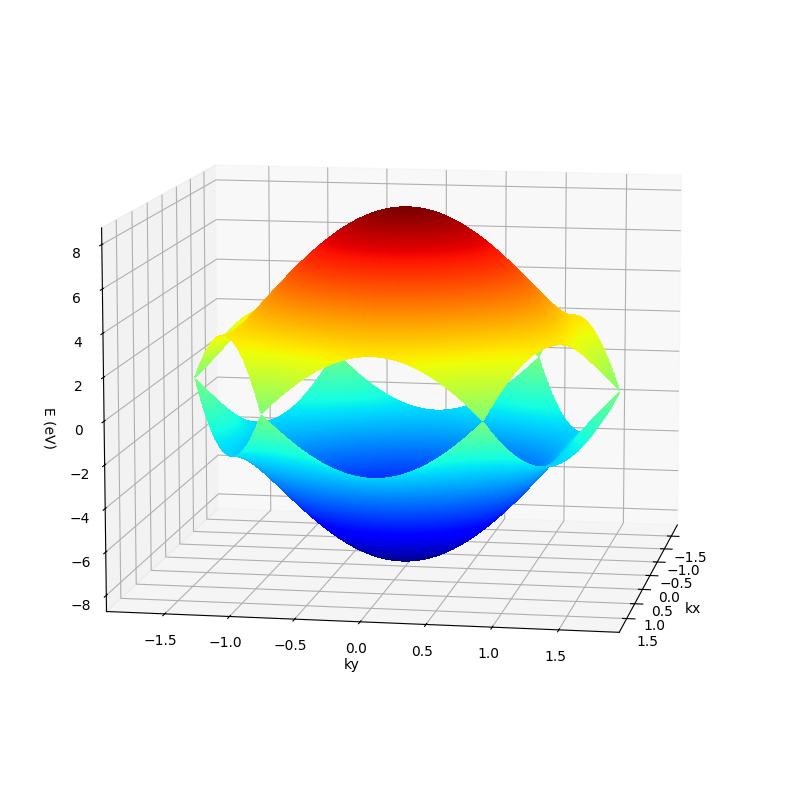

In [4]:
kx = np.linspace(-b/np.sqrt(3),b/np.sqrt(3),500)
ky = np.linspace(-b/np.sqrt(3),b/np.sqrt(3),500)

kxx, kyy = np.meshgrid(kx,ky)

VB, CB = E_Tb(kxx,kyy)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(VB.min(), CB.min())
E_max = max(VB.max(), CB.max())
norm = plt.Normalize(vmin=E_min, vmax=E_max)
cmap = plt.get_cmap('jet')

radius_k = b / np.sqrt(3)

mask = (np.abs(kxx) <= radius_k * np.sqrt(3) / 2) & \
       (np.abs(np.sqrt(3) * kyy + kxx) <= radius_k * np.sqrt(3)) & \
       (np.abs(np.sqrt(3) * kyy - kxx) <= radius_k * np.sqrt(3))

# Bande de valence
CB_masked = np.where(mask, CB, np.nan)
VB_masked = np.where(mask, VB, np.nan)

ax.plot_surface(kxx, kyy, VB_masked, rstride=1, cstride=1, 
                facecolors=cmap(norm(VB)),
                linewidth=0, antialiased=False, alpha=0.7, shade=False)

# Bande de conduction
ax.plot_surface(kxx, kyy, CB_masked, rstride=1, cstride=1, 
                facecolors=cmap(norm(CB)),
                linewidth=0, antialiased=False, alpha=0.7, shade=False)

ax.set_xlabel('kx')
ax.set_ylabel('ky')
ax.set_zlabel('E (eV)')
ax.view_init(10,10,0)

plt.tight_layout()
plt.show()

### Approximation linéaire du modèle au point K

In [4]:
def Dirac_c(kx,ky,epsi=0):

    CB = epsi + hbarr*v_F_hbr*np.sqrt(kx**2 +ky**2)
    VB = epsi - hbarr*v_F_hbr*np.sqrt(kx**2 +ky**2)

    return VB, CB

In [11]:
qx = np.linspace(-b/4,b/4,100)
qy = np.linspace(-b/4,b/4,100)

qxx_D, qyy_D = np.meshgrid(qx,qy)
qxx_Tb, qyy_Tb = np.meshgrid(qx+b_1[0]*(2/3)+b_2[0]/3,qy+b_1[1]*(2/3)+b_2[1]/3)

VB_K_D, CB_K_D = Dirac_c(qxx_D,qyy_D)

VB_K_Tb, CB_K_Tb = E_Tb(qxx_Tb,qyy_Tb)


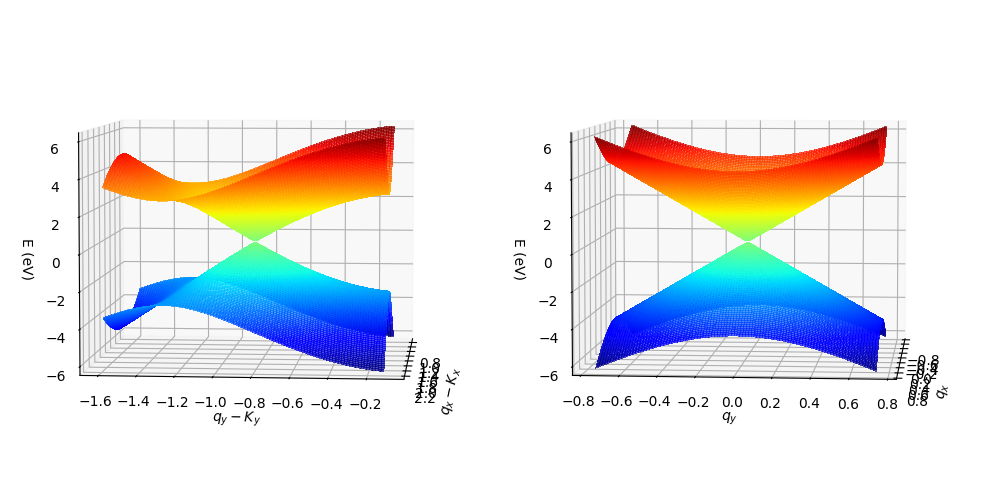

In [12]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(121, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(VB_K_Tb.min(), CB_K_Tb.min())
E_max = max(VB_K_Tb.max(), CB_K_Tb.max())
norm = plt.Normalize(vmin=E_min, vmax=E_max)
cmap = plt.get_cmap('jet')

# Bande de valence
ax.plot_surface(qxx_Tb, qyy_Tb, VB_K_Tb, rstride=1, cstride=1, 
                facecolors=cmap(norm(VB_K_Tb)),
                linewidth=0, antialiased=False, alpha=0.7, shade=False)

# Bande de conduction
ax.plot_surface(qxx_Tb, qyy_Tb, CB_K_Tb, rstride=1, cstride=1, 
                facecolors=cmap(norm(CB_K_Tb)),
                linewidth=0, antialiased=False, alpha=0.7, shade=False)

ax.set_xlabel('$q_x-K_x$ ')
ax.set_ylabel('$q_y-K_y$')
ax.set_zlabel('E (eV)')
ax.view_init(5,5,0)

# Approximation autour de K
ax1 = fig.add_subplot(122, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(VB_K_D.min(), CB_K_D.min())
E_max = max(VB_K_D.max(), CB_K_D.max())
norm = plt.Normalize(vmin=E_min, vmax=E_max)
cmap = plt.get_cmap('jet')

# Bande de valence
ax1.plot_surface(qxx_D, qyy_D, VB_K_D, rstride=1, cstride=1, 
                facecolors=cmap(norm(VB_K_D)),
                linewidth=0, antialiased=False, alpha=0.7, shade=False)

# Bande de conduction
ax1.plot_surface(qxx_D, qyy_D, CB_K_D, rstride=1, cstride=1, 
                facecolors=cmap(norm(CB_K_D)),
                linewidth=0, antialiased=False, alpha=0.7, shade=False)

ax1.set_xlabel('$q_x$')
ax1.set_ylabel('$q_y$')
ax1.set_zlabel('E (eV)')
ax1.view_init(5,5,0)


plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def E_error(q_max,n=150,prt=True):

    K = b_1*(2/3) + b_2/3
    Knorm = np.linalg.norm(K)

    # Grille autour de K
    qx = np.linspace(-q_max, q_max, n)
    qy = np.linspace(-q_max, q_max, n)
    qxx, qyy = np.meshgrid(qx, qy)

    # Coordonnées absolues (décalées au point K)
    kxx = qxx + K[0]
    kyy = qyy + K[1]

    # Énergies
    VB_D, CB_D = Dirac_c(qxx, qyy)
    VB_TB, CB_TB = E_Tb(kxx, kyy)

    # Erreur
    erreur = np.abs(CB_TB - CB_D)

    # Masque circulaire
    q_norm = np.sqrt(qxx**2 + qyy**2)
    mask = q_norm < q_max
    erreur[~mask] = np.nan

    # Statistiques simples
    if prt :
        print(f"Erreur moyenne : {np.nanmean(erreur):.4f} eV")
        print(f"Erreur max     : {np.nanmax(erreur):.4f} eV")
        print(f"Erreur relative: {np.nanmean(erreur)/np.nanmean(CB_D[mask])*100:.2f}%")

    val = np.array([np.nanmean(erreur),np.nanmax(erreur),np.nanmean(erreur)/np.nanmean(CB_D[mask])*100])

    return erreur, qx, qy, val

Erreur moyenne : 0.0001 eV
Erreur max     : 0.0002 eV
Erreur relative: 0.17%
195496


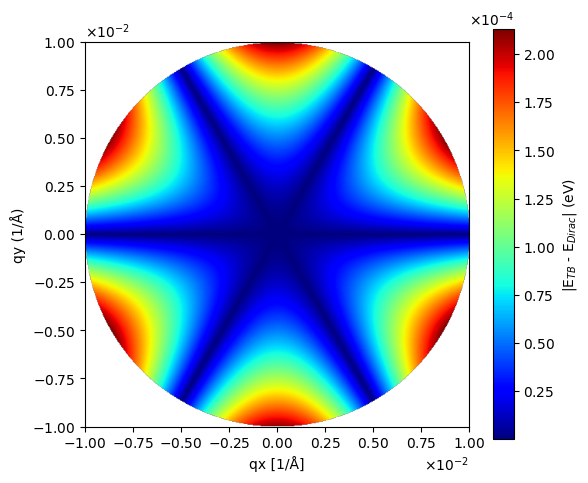

In [10]:
from matplotlib.ticker import ScalarFormatter

qmax = 1e-2
erreur, qx, qy, _ = E_error(qmax, 500)

print(np.sum(erreur > 0))

plt.figure(figsize=(6, 5))
im = plt.imshow(erreur, origin='lower', 
                extent=[qx.min(), qx.max(), qy.min(), qy.max()],
                cmap='jet')

# Créer la colorbar et récupérer l'objet
cbar = plt.colorbar(im, label=r'|E$_{TB}$ - E$_{Dirac}$| (eV)')

# Forcer la notation scientifique pour les axes
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, -2))  
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Forcer la notation scientifique pour la colorbar
cbar_formatter = ScalarFormatter(useMathText=True)
cbar_formatter.set_scientific(True)
cbar_formatter.set_powerlimits((-4, -4))  # ou autre limite selon vos données
cbar.ax.yaxis.set_major_formatter(cbar_formatter)

plt.xlabel('qx [1/Å]')
plt.ylabel('qy (1/Å)')
plt.tight_layout()
plt.savefig(f'errormap.jpg', dpi=600)
plt.show()

In [11]:
qmax_r = np.linspace(0.0000001,0.1,500)
er = []

for qmax in qmax_r:
    _, _, _, v = E_error(qmax,500,False)
    er.append(v[2])

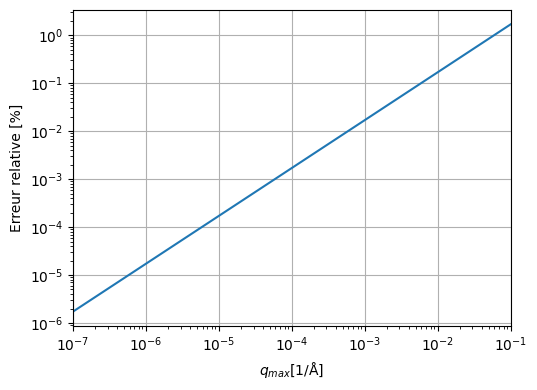

In [12]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1)

ax1.loglog(qmax_r,np.array(er))
ax1.set_xlabel(r"$q_{max}$[1/Å]")
ax1.set_ylabel("Erreur relative [%]")
ax1.set_xlim((qmax_r[0],qmax_r[-1]))
ax1.grid()
plt.tight_layout()
plt.savefig(f'meanerror.jpg', dpi=600)
plt.show()

Erreur moyenne : 0.0000 eV
Erreur max     : 0.0000 eV
Erreur relative: 0.02%


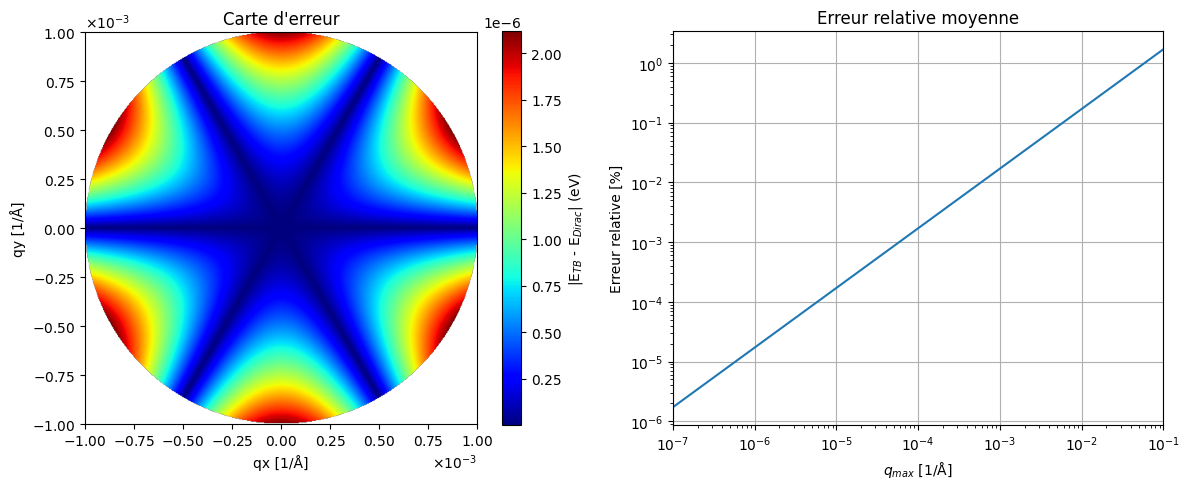

In [14]:
from matplotlib.ticker import ScalarFormatter

qmax = 0.001
erreur, qx, qy, _ = E_error(qmax, 500)

# Créer la figure avec 2 sous-graphiques
fig = plt.figure(figsize=(12, 5))

# Premier subplot : carte d'erreur
ax1 = fig.add_subplot(1, 2, 1)
im = ax1.imshow(erreur, origin='lower', 
                extent=[qx.min(), qx.max(), qy.min(), qy.max()],
                cmap='jet')

# Colorbar pour le premier subplot
cbar = plt.colorbar(im, ax=ax1, label=r'|E$_{TB}$ - E$_{Dirac}$| (eV)')

# Formatter pour la colorbar
cbar_formatter = ScalarFormatter(useMathText=True)
cbar_formatter.set_scientific(True)
cbar_formatter.set_powerlimits((-3, -3))
cbar.ax.yaxis.set_major_formatter(cbar_formatter)
cbar.update_ticks()  # Important: mettre à jour les ticks

# Formatter pour les axes
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, -3))  
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('qx [1/Å]')
ax1.set_ylabel('qy [1/Å]')
ax1.set_title('Carte d\'erreur')

# Deuxième subplot : erreur relative
ax2 = fig.add_subplot(1, 2, 2)
ax2.loglog(qmax_r, np.array(er))
ax2.set_xlabel(r"$q_{max}$ [1/Å]")
ax2.set_ylabel("Erreur relative [%]")
ax2.set_xlim((qmax_r[0], qmax_r[-1]))
ax2.grid()
ax2.set_title('Erreur relative moyenne')

plt.tight_layout()
plt.savefig('combined_figure.jpg', dpi=600, bbox_inches='tight')
plt.show()

In [93]:
from graphen import *
G = grphn()
hbar = G.h/(2*np.pi)

E_max = G.v_F_hbr * qmax
print(E_max)

0.005751


## Densité d'état

In [12]:
def g_K_lin(E):
    return 2*np.abs(E)/(np.pi*(hbarr*v_F_hbr)**2)

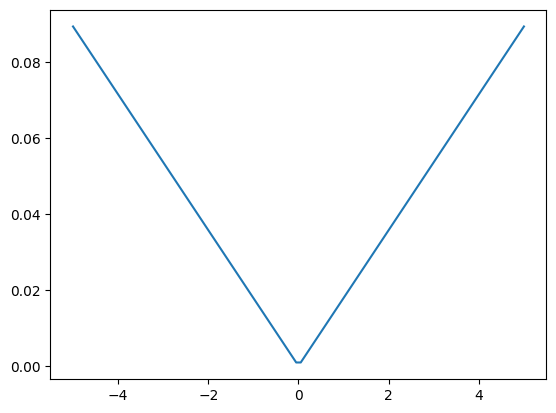

In [13]:
en = np.linspace(-5,5,100)
plt.plot(en,g_K_lin(en))

In [14]:
kx_range = (-b, b)
ky_range = (-b, b)
n_points = 7500  
kx = np.linspace(kx_range[0], kx_range[1], n_points)
ky = np.linspace(ky_range[0], ky_range[1], n_points)
kxx, kyy = np.meshgrid(kx, ky)

radius_k = b / np.sqrt(3)
mask = (np.abs(kxx) <= radius_k * np.sqrt(3) / 2) & \
       (np.abs(np.sqrt(3) * kyy + kxx) <= radius_k * np.sqrt(3)) & \
       (np.abs(np.sqrt(3) * kyy - kxx) <= radius_k * np.sqrt(3))

_, CB = E_Tb(kxx, kyy)
CB_masked = CB[mask] 

n_bins = 3000
E_levels = np.linspace(0, 10, n_bins + 1) 
dE = E_levels[1] - E_levels[0]

DOSp, _ = np.histogram(CB_masked, bins=E_levels)

total_k_points = len(CB_masked)

norm_factor = 2 / (total_k_points * dE)
DOSp = DOSp * norm_factor

DOSm = DOSp[::-1]
DOS = np.concatenate([DOSm, DOSp])

E_centers_p = (E_levels[:-1] + E_levels[1:]) / 2
E_centers = np.concatenate([-E_centers_p[::-1], E_centers_p])

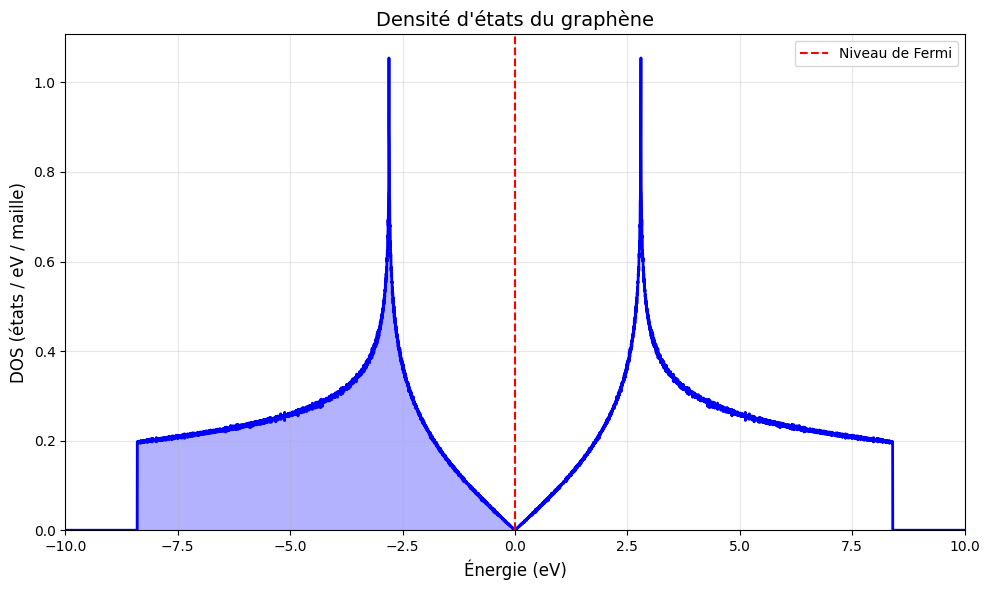

3.9999999999999996


In [15]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(E_centers, DOS, 'b-', linewidth=2)
axes.fill_between(E_centers[E_centers<0], 0, DOS[E_centers<0], alpha=0.3, color='b')
axes.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Niveau de Fermi')
axes.set_xlabel('Énergie (eV)', fontsize=12)
axes.set_ylabel('DOS (états / eV / maille)', fontsize=12)
axes.set_title('Densité d\'états du graphène', fontsize=14)
axes.grid(True, alpha=0.3)
axes.set_ylim(bottom=0)
axes.set_xlim(-10, 10)
axes.legend()
plt.tight_layout()
plt.show()

print(np.trapezoid(DOS,E_centers))

## Conduction, modèles théoriques

#### Capacité quantique

In [16]:
def find_nearest(X, x):
    return np.argmin(np.abs(X - x))